In [190]:
import matplotlib.pyplot as plt
import numpy as np
import openmm
from openmm import unit
from openmm import Continuous1DFunction, CustomNonbondedForce

from colloids.abstracts import ColloidPotentialsAbstract
from colloids.colloid_potentials_parameters import ColloidPotentialsParameters

%matplotlib inline

In [178]:
radius1 = 105.0
radius2 = 85.0
#sigma_avg = (radius1 + radius2)/2 #consider the method used to define this average; there are several to choose from

brush_length = 10.0
brush2=2*brush_length

brush_density=0.09

phi = 1
rdep = 5

h_vals = np.linspace(15.0, 36.0, num=1000)

In [179]:
def expected_steric_repulsion(steric_prefactor, h):
        """
        Return the steric potential from the Alexander-de Gennes polymer brush model for the given 
        surface-to-surface separations.
        """
        brush2 = 2.0 * brush_length
        
        return (steric_prefactor * np.where(h <= brush2,
                                     28.0 * (np.power(brush2 / h, 0.25) - 1.0)
                                     + 20.0 / 11.0 * (1.0 - np.power(h / brush2, 2.75))
                                     + 12.0 * (h / brush2 - 1.0),
                                     0.0) )

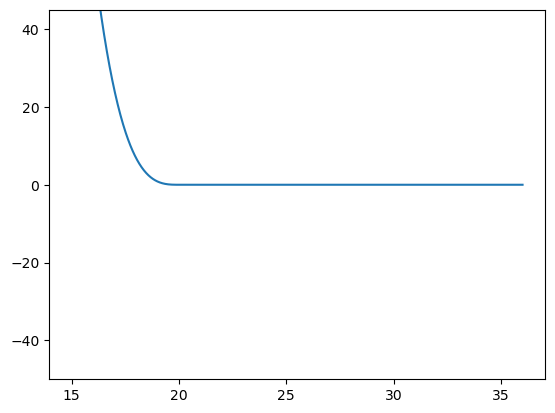

In [180]:
steric_prefactor = 16*np.pi*sigma_avg*(brush2**2)*(brush_density**(3./2))/35.
potential_vals = expected_steric_repulsion(steric_prefactor, h_vals)
plt.plot(h_vals, potential_vals)
plt.ylim(-50, 45)
plt.show()

In [206]:
def expected_AO_potential_1(h, radius1, radius2, brush_length, phi, rdep):
    """
    Return the Asakura-Oosawa potential (generalized to asymmetric sphere) for a colloidal solution in a 
    background of non-adsorbing polymers.
    
    h: surface-to-surface particle separation distance
    radius1: radius of first type of colloidal particle
    radius2: radius of second type of colloidal particle
    brush_length: length of polymer brush
    phi: volume fraction of polymer depletants (must be between 0 and 1)
    rdep: radius of polymer depletants
    """
    
    sigmaD1 = brush_length + radius1 
    sigmaD2 = brush_length + radius2
    rcc = h + radius1 + radius2 #center-to-center separation distance 
    q1 = sigmaD1/rdep #ratio of particle sizes: colloid1 to polymer
    q2 = sigmaD2/rdep ##ratio of particle sizes: colloid2 to polymer
    n = rcc/rdep

    
    return ( -phi/16 * np.where(rcc <= (sigmaD1 + sigmaD2 + 2*rdep),
                                    (q1+q2+2-n)**2*(n+2*(q1+q2+2)-3/n*(q1**2+q2**2-2*q1*q2)),
                                    0.0))

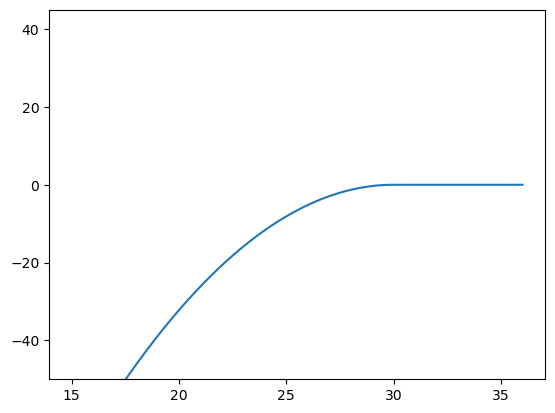

In [207]:
ao_vals = expected_AO_potential_1(h_vals, radius1, radius2, brush_length, phi, rdep)
plt.plot(h_vals, ao_vals)
plt.ylim(-50, 45)
plt.show()

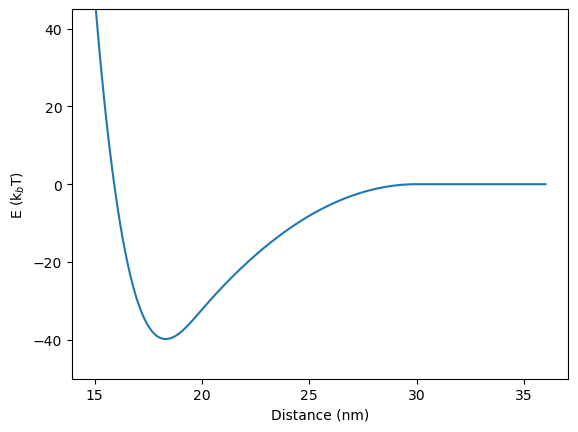

In [208]:
plt.plot(h_vals, potential_vals+ ao_vals1)
plt.xlabel('Distance (nm)')
plt.ylabel('E (k$_b$T)')
plt.ylim(-50, 45)
plt.show()

In [ ]:
def get_potentials(h_values, radius_one, radius_two, phi, radius_depletant, brush_length, platform_name="Reference"):
    
    # Set up system.
    system = openmm.System()
    
    # Make system very large so that we do not care about periodic boundaries.
    side_length = 200.0 * (max(h_values) + radius_one.value_in_unit(unit.nanometer) + radius_two.value_in_unit(unit.nanometer)) 
    system.setDefaultPeriodicBoxVectors([side_length, 0.0, 0.0],
                                        [0.0, side_length, 0.0],
                                        [0.0, 0.0, side_length])
    
    depletion_potentials = DepletionPotentialsAlgebraic(phi, depletant_radius, brush_length)
    
    # Add two particles to the system and forces (mass is unimportant for the potential).
    system.addParticle(mass=1.0)
    depletion_potentials.add_particle(radius=radius_one) #, surface_potential=surface_potential_one)
    system.addParticle(mass=1.0)
    depletion_potentials.add_particle(radius=radius_two) #, surface_potential=surface_potential_two)

    # Add forces.
    for potential in depletion_potentials.yield_potentials():
        system.addForce(potential)
        
    for force in system.getForces():
        print(f"Energy function: {force.getEnergyFunction()}")
        print(f"Nonbonded method: {force.getNonbondedMethod()}, Cutoff distance: {force.getCutoffDistance()}")
        assert force.usesPeriodicBoundaryConditions()
        assert not force.getUseLongRangeCorrection()
    
    # Set up platform and context. The platform_name is typically Reference or CUDA.
    platform = openmm.Platform.getPlatformByName(platform_name)
    dummy_integrator = openmm.LangevinIntegrator(
        parameters.temperature.value_in_unit(unit.kelvin), 0.0, 0.0)
    context = openmm.Context(system, dummy_integrator, platform)
    print(f"Using {context.getPlatform().getName()} platform.")
    if context.getPlatform().getName() == "CUDA":
        for cuda_property in ("Precision", "TempDirectory", "UseCpuPme", "DeviceIndex", "UseBlockingSync", "DeterministicForces"):
            print(f"{cuda_property}: {context.getPlatform().getPropertyValue(context, cuda_property)}")
    
    
    potential_energies = np.zeros(len(h_values))
    for h_index, h_value in enumerate(h_values):
        context.setPositions([[(radius_one + radius_two).value_in_unit(unit.nanometer) + h_value, 0.0, 0.0], [0.0, 0.0, 0.0]])
        state = context.getState(getEnergy=True)
        potential_energies[h_index] = (
            state.getPotentialEnergy()
            / (unit.BOLTZMANN_CONSTANT_kB * parameters.temperature * unit.AVOGADRO_CONSTANT_NA)
        )
    
    return potential_energies

In [ ]:
potential_vals = get_potentials(h_vals, radius1, radius2, phi, rdept, brush_length, platform_name="Reference")

In [ ]:
ao_exp = expected_AO_potential_1(h_vals, radius1, radius2, brush_length, phi, rdep)

plt.plot(h_vals, ao_exp,  color="k")
plt.plot(h_vals, potential_vals, color='blue', marker="x")
plt.xlabel("h")
plt.ylabel("PE")
plt.ylim(-50, 45)
plt.show()

In [149]:
def expected_AO_potential_2(r, radius1, brush_length, phi, rdep):
    """
    Return the Asakura-Oosawa potential (generalized to asymmetric sphere) for a colloidal solution in a 
    background of non-adsorbing polymers.

    phi:number fraction of polymer depletants, must be between 0 and 1
    sigma1: radius of colloid particle
    q: ratio of particle sizes
    
    
    radius1: radius of first type of colloidal particle
    radius2: radius of second type of colloidal particle
    brush_length: length of polymer brush
    phi: number fraction of polymer depletants
    rdep: radius of polymer depletants
    rcc: center-to-center separation distance  
    h: surface-to-surface particle separation distance 
    """

    q = rdep/radius1 

    #sigma1 = brush_length + radius1
    sigma1 = radius1
    
    if r <= (2*radius1 + 2*rdep):
        
        prefactor = -phi/16 #* np.pi/12
        term1 = (2 * (2*radius1 + 2*rdep)**3)
        term2 = (3 * (2*radius1 + 2*rdep)**2 * r)
        term3 = r**3
        
        #prefactor = -phi/16 * (1+q)**3/q**3
        #term1 = 3*r / (2 * sigma1 * (1+q))
        #term2 = r**3 / (2 * sigma1**3 *(1+q)**3)
    
    #rcc <= (sigmaD1 + sigmaD2 + 2*rdep):

        #AO_potential = prefactor * (1 - term1 + term2)
        AO_potential = prefactor * (term1 - term2 + term3)
    
    else:
        
        AO_potential = 0 
        
    return AO_potential 
    

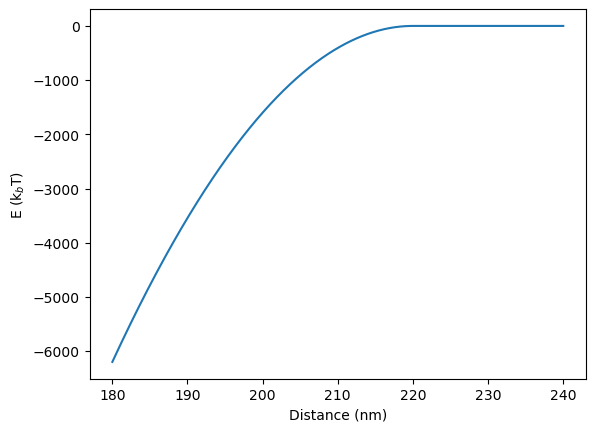

In [150]:
r_vals = np.linspace(180.0, 240.0, num=1000)

ao_vals2 = []

for r in r_vals:
    
    ao = expected_AO_potential_2(r, radius1, brush_length, 0.1, 5)

    ao_vals2.append(ao)
    
plt.plot(r_vals, ao_vals2)
#plt.plot(h_vals, ao_vals1)
#plt.plot(h_vals, potential_vals)
#plt.plot(h_vals, potential_vals+ ao_vals)
plt.xlabel('Distance (nm)')
plt.ylabel('E (k$_b$T)')
#plt.ylim(-50, 45)
plt.show()

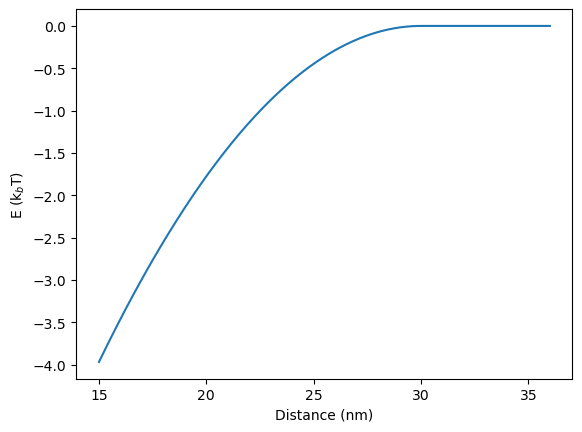

In [128]:
h_vals = np.linspace(15.0, 36.0, num=1000)


ao_vals1 = []

for h in h_vals:
    
    ao = expected_AO_potential_1(h, radius1, radius1, brush_length, 0.05, 5)

    ao_vals1.append(ao)
    
plt.plot(h_vals, ao_vals1)
#plt.plot(h_vals, potential_vals)
#plt.plot(h_vals, potential_vals+ ao_vals)
plt.xlabel('Distance (nm)')
plt.ylabel('E (k$_b$T)')
#plt.ylim(-50, 45)
plt.show()